# Phase 3: Adversarial Robustness Analysis

Step 3.1 — Feature-space perturbation: how much noise does it take to flip a classification?

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load best category model and test split
# (re-run 02_modeling.ipynb first if models/ is empty)
best_cat_model = joblib.load('models/category_best.joblib')

features = pd.read_csv('data/features.csv')
from sklearn.model_selection import train_test_split

X = features.drop(columns=['is_vpn', 'app', 'category'])
y_cat = features['category']
y_vpn = features['is_vpn'].astype(int)

_, X_temp, _, yc_temp, _, yv_temp = train_test_split(
    X, y_cat, y_vpn, test_size=0.30, random_state=42, stratify=y_cat)
X_val, X_test, y_cat_val, y_cat_test, _, _ = train_test_split(
    X_temp, yc_temp, yv_temp, test_size=0.50, random_state=42, stratify=yc_temp)

print(f'Test set: {X_test.shape}')
print(y_cat_test.value_counts())

Test set: (3470, 113)
category
FILE_TRANSFER    2916
STREAMING         265
CHAT              192
VOIP               92
C2                  5
Name: count, dtype: int64


In [2]:
# Keep only correctly classified test samples -- these are the attack targets
preds_clean = best_cat_model.predict(X_test)
correct_mask = preds_clean == y_cat_test.values

X_correct = X_test[correct_mask].reset_index(drop=True)
y_correct  = y_cat_test[correct_mask].reset_index(drop=True)

print(f'Correctly classified: {correct_mask.sum()} / {len(y_cat_test)}')
print(y_correct.value_counts())

Correctly classified: 3449 / 3470
category
FILE_TRANSFER    2898
STREAMING         265
CHAT              192
VOIP               92
C2                  2
Name: count, dtype: int64


In [3]:
# Feature standard deviations -- used to express perturbation budget as
# a fraction of each feature's natural variability
feat_std = X_test.std()

# Top features to perturb (use SHAP-ranked or just all numeric features).
# We perturb the top-30 most important features for efficiency.
# Replace with top20 from SHAP if available; otherwise use variance ranking.
top_features = feat_std.nlargest(30).index.tolist()
print(f'Perturbing {len(top_features)} features')
print(top_features[:10], '...')

Perturbing 30 features
['bytes_per_sec', 'idle_time', 'out_iat_max', 'flow_iat_max', 'in_iat_max', 'out_iat_mean', 'in_iat_mean', 'out_iat_min', 'in_iat_min', 'mean_burst_pkts'] ...


In [4]:
# Step 3.1 -- Incremental perturbation sweep
#
# Perturbation budget k means we add Gaussian noise with std = k * feat_std
# to the selected features. We record the budget at which each sample flips.
#
# Physical constraint: timing and size features can only INCREASE
# (adversary can pad/delay but not shrink). We enforce this by clipping
# negative deltas to 0 for those feature families.

def is_constrained(feat_name):
    """Return True if this feature can only increase (realistic attacker)."""
    return any(feat_name.startswith(p) for p in
               ('out_size', 'in_size', 'out_iat', 'in_iat', 'flow_iat',
                'total_bytes', 'bytes_per_sec', 'log_out', 'log_in'))

budgets = np.linspace(0, 2.0, 41)  # 0% to 200% of feat_std in 41 steps
rng = np.random.default_rng(42)

# flip_budget[i] = smallest budget that caused sample i to misclassify
#                  (np.inf if it never flipped within the sweep)
flip_budget = np.full(len(X_correct), np.inf)

for k in budgets:
    if k == 0:
        continue
    X_perturbed = X_correct.copy()
    for feat in top_features:
        delta = rng.normal(0, k * feat_std[feat], size=len(X_correct))
        if is_constrained(feat):
            delta = np.clip(delta, 0, None)   # only allow increases
        X_perturbed[feat] = X_perturbed[feat] + delta

    preds_adv = best_cat_model.predict(X_perturbed)
    flipped   = preds_adv != y_correct.values
    # Record first flip
    flip_budget = np.where((flip_budget == np.inf) & flipped, k, flip_budget)

print(f'Samples that never flipped within budget 2.0: {(flip_budget == np.inf).sum()}')
print(f'Mean flip budget (excluding never-flipped):   {flip_budget[flip_budget < np.inf].mean():.3f}')

Samples that never flipped within budget 2.0: 785
Mean flip budget (excluding never-flipped):   0.792


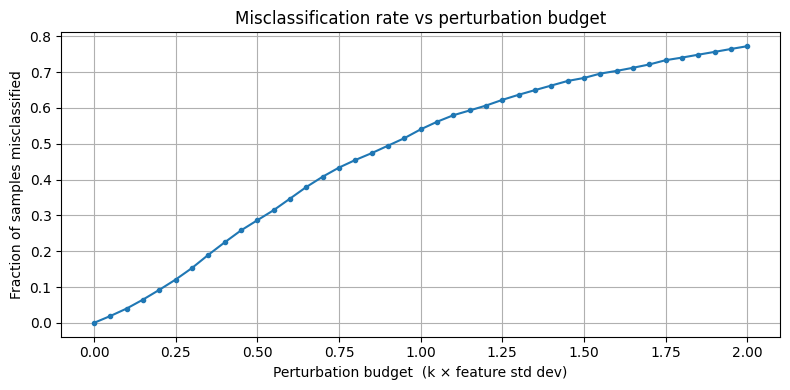

In [5]:
# Misclassification rate vs perturbation budget (across all classes)
misclassification_rate = [(flip_budget <= k).mean() for k in budgets]

plt.figure(figsize=(8, 4))
plt.plot(budgets, misclassification_rate, marker='o', markersize=3)
plt.xlabel('Perturbation budget  (k × feature std dev)')
plt.ylabel('Fraction of samples misclassified')
plt.title('Misclassification rate vs perturbation budget')
plt.grid(True)
plt.tight_layout()
plt.show()

Per-class robustness scores (higher = harder to evade):
VOIP             1.6804
CHAT             1.6750
C2               1.0750
FILE_TRANSFER    1.0680
STREAMING        0.4045
Name: Mean flip budget, dtype: float64


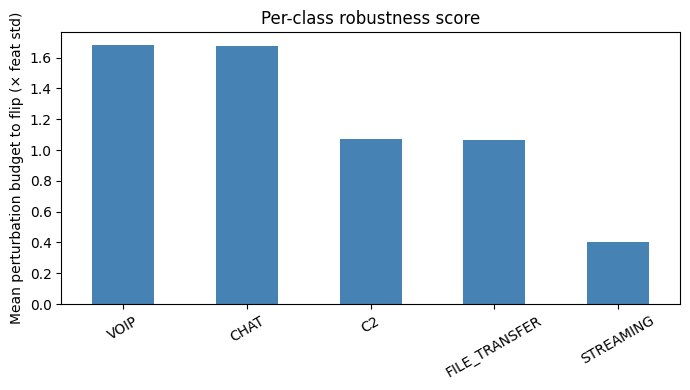

In [6]:
# Per-class robustness score
# Defined as the mean perturbation budget required to flip samples of that class.
# Higher = more robust.

robustness = {}
for cls in y_correct.unique():
    mask = y_correct == cls
    budgets_cls = flip_budget[mask]
    # Treat never-flipped as the max budget (conservative)
    budgets_cls = np.where(budgets_cls == np.inf, budgets[-1], budgets_cls)
    robustness[cls] = budgets_cls.mean()

rob_df = pd.Series(robustness).sort_values(ascending=False).rename('Mean flip budget')
print('Per-class robustness scores (higher = harder to evade):')
print(rob_df.round(4))

rob_df.plot.bar(figsize=(7, 4), color='steelblue')
plt.ylabel('Mean perturbation budget to flip (× feat std)')
plt.title('Per-class robustness score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Most sensitive features (smallest budget to flip 10% of samples):
bytes_per_sec      2.2
idle_time          2.2
out_iat_max        2.2
flow_iat_max       2.2
in_iat_max         2.2
out_iat_mean       2.2
in_iat_mean        2.2
out_iat_min        2.2
in_iat_min         2.2
mean_burst_pkts    2.2
flow_iat_std       2.2
flow_iat_mean      2.2
in_size_max        2.2
out_size_max       2.2
in_iat_std         2.2
out_iat_std        2.2
in_size_p75        2.2
in_size_median     2.2
in_size_mean       2.2
n_bursts           2.2
dtype: float64


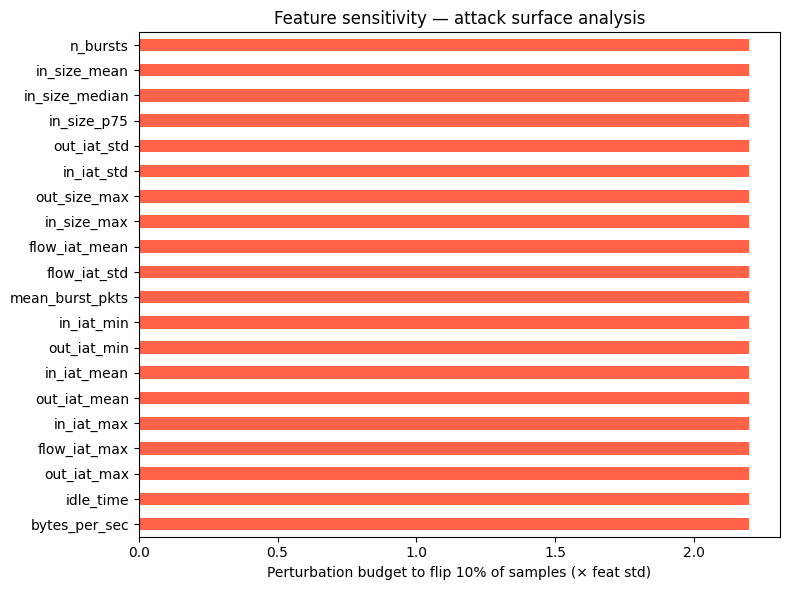

In [7]:
# Attack surface analysis -- which individual features cause flips fastest?
# For each feature, perturb ONLY that feature and find the smallest budget
# that flips at least 10% of samples.

FLIP_THRESHOLD = 0.10   # 10% misclassification rate triggers detection
rng2 = np.random.default_rng(0)
feature_sensitivity = {}

for feat in top_features:
    for k in budgets:
        if k == 0:
            continue
        X_p = X_correct.copy()
        delta = rng2.normal(0, k * feat_std[feat], size=len(X_correct))
        if is_constrained(feat):
            delta = np.clip(delta, 0, None)
        X_p[feat] = X_p[feat] + delta
        rate = (best_cat_model.predict(X_p) != y_correct.values).mean()
        if rate >= FLIP_THRESHOLD:
            feature_sensitivity[feat] = k
            break
    else:
        feature_sensitivity[feat] = np.inf

sens_df = (pd.Series(feature_sensitivity)
             .replace(np.inf, budgets[-1] * 1.1)
             .sort_values()
             .head(20))

print(f'Most sensitive features (smallest budget to flip {FLIP_THRESHOLD:.0%} of samples):')
print(sens_df.round(4))

sens_df.sort_values().plot.barh(figsize=(8, 6), color='tomato')
plt.xlabel('Perturbation budget to flip 10% of samples (× feat std)')
plt.title('Feature sensitivity — attack surface analysis')
plt.tight_layout()
plt.show()

## Step 3.2 - Evasion Attack Simulation

Target: make C2 flows classify as CHAT with minimum realistic perturbation.
Method: greedy coordinate descent using finite differences (tree models are not differentiable).

In [8]:
# Step 3.2 setup -- run this if you are starting here without Step 3.1 in memory
import joblib, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

best_cat_model = joblib.load("models/category_best.joblib")

features = pd.read_csv("data/features.csv")
X     = features.drop(columns=["is_vpn", "app", "category"])
y_cat = features["category"]
y_vpn = features["is_vpn"].astype(int)

_, X_temp, _, yc_temp, _, yv_temp = train_test_split(
    X, y_cat, y_vpn, test_size=0.30, random_state=42, stratify=y_cat)
X_val, X_test, y_cat_val, y_cat_test, _, _ = train_test_split(
    X_temp, yc_temp, yv_temp, test_size=0.50, random_state=42, stratify=yc_temp)

preds_clean  = best_cat_model.predict(X_test)
correct_mask = preds_clean == y_cat_test.values
X_correct    = X_test[correct_mask].reset_index(drop=True)
y_correct    = y_cat_test[correct_mask].reset_index(drop=True)

feat_std     = X_test.std()
top_features = feat_std.nlargest(30).index.tolist()
budgets      = np.linspace(0, 2.0, 41)

def is_constrained(feat_name):
    return any(feat_name.startswith(p) for p in
               ("out_size", "in_size", "out_iat", "in_iat", "flow_iat",
                "total_bytes", "bytes_per_sec", "log_out", "log_in"))

print(f"Model loaded. Correct test samples: {len(X_correct)}")
print(y_correct.value_counts())

Model loaded. Correct test samples: 3449
category
FILE_TRANSFER    2898
STREAMING         265
CHAT              192
VOIP               92
C2                  2
Name: count, dtype: int64


In [9]:
# Evasion attack: C2 -> CHAT via greedy coordinate descent
# Constraint: only INCREASE features in the constrained set (pad/delay, never shrink)

TARGET_CLASS = 'CHAT'
ATTACK_CLASS = 'C2'
STEP_SIZE    = 0.05   # fraction of feat_std per step
MAX_STEPS    = 200    # cap iterations per sample

classes    = list(best_cat_model.classes_)
target_idx = classes.index(TARGET_CLASS)


def evade_sample(x):
    x_adv = x.copy().astype(float)
    total_delta = np.zeros(len(x_adv))

    for step in range(MAX_STEPS):
        prob = best_cat_model.predict_proba(x_adv.values.reshape(1, -1))[0]
        if classes[prob.argmax()] == TARGET_CLASS:
            return {'success': True, 'steps': step,
                    'l2_norm': float(np.linalg.norm(total_delta)),
                    'x_adv': x_adv}

        best_gain, best_feat, best_delta_val = -np.inf, None, 0.0
        for feat in top_features:
            step_size = STEP_SIZE * feat_std[feat]
            directions = [step_size] if is_constrained(feat) else [step_size, -step_size]
            for d in directions:
                x_try = x_adv.copy()
                x_try[feat] += d
                p = best_cat_model.predict_proba(x_try.values.reshape(1, -1))[0]
                if p[target_idx] > best_gain:
                    best_gain, best_feat, best_delta_val = p[target_idx], feat, d

        if best_feat is None:
            break
        feat_idx = list(x_adv.index).index(best_feat)
        x_adv[best_feat] += best_delta_val
        total_delta[feat_idx] += best_delta_val

    return {'success': False, 'steps': MAX_STEPS,
            'l2_norm': float(np.linalg.norm(total_delta)),
            'x_adv': x_adv}


print('evade_sample defined')

evade_sample defined


In [10]:
import warnings
warnings.filterwarnings('ignore')


# Apply evasion to all correctly classified C2 test samples
c2_mask = y_correct == ATTACK_CLASS
X_c2    = X_correct[c2_mask].reset_index(drop=True)
print(f'C2 samples to attack: {len(X_c2)}')

results_evasion = [evade_sample(X_c2.iloc[i]) for i in range(len(X_c2))]
success_flags   = [r['success'] for r in results_evasion]
l2_norms        = [r['l2_norm']  for r in results_evasion]

success_rate = np.mean(success_flags)
print(f'Evasion success rate:              {success_rate:.1%}')
print(f'Mean L2 perturbation (all):        {np.mean(l2_norms):.4f}')
if any(success_flags):
    succ_l2 = [l for l, s in zip(l2_norms, success_flags) if s]
    print(f'Mean L2 perturbation (successful): {np.mean(succ_l2):.4f}')

C2 samples to attack: 2
Evasion success rate:              0.0%
Mean L2 perturbation (all):        53542.5701


In [11]:
# Perturbation magnitude distribution for successful evasions
successful_l2 = [r['l2_norm'] for r in results_evasion if r['success']]

if successful_l2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(successful_l2, bins=15, color='tomato', edgecolor='white')
    axes[0].set_xlabel('L2 perturbation magnitude')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'C2->CHAT evasion: perturbation magnitude\n'
                      f'({len(successful_l2)}/{len(X_c2)} samples evaded)')

    steps_taken = [r['steps'] for r in results_evasion if r['success']]
    axes[1].hist(steps_taken, bins=15, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Steps to evasion')
    axes[1].set_title('Steps needed per successful evasion')

    plt.tight_layout()
    plt.show()
else:
    print('No successful evasions -- model is robust to this attack.')

No successful evasions -- model is robust to this attack.


In [12]:
# Which features were perturbed most in successful evasions?
if any(success_flags):
    adv_X = pd.DataFrame(
        [r['x_adv'] for r in results_evasion if r['success']],
        columns=X_c2.columns
    )
    orig_X = X_c2[[r['success'] for r in results_evasion]]
    mean_delta = pd.Series(
        np.abs(adv_X.values - orig_X.values).mean(axis=0),
        index=X_c2.columns
    ).nlargest(15)

    mean_delta.sort_values().plot.barh(figsize=(8, 5), color='tomato')
    plt.xlabel('Mean |perturbation|')
    plt.title('Features most perturbed during C2->CHAT evasion')
    plt.tight_layout()
    plt.show()

## Step 3.3 - Adversarial Training (Hardening)

Augment training set with adversarial C2 examples (labelled as C2), retrain, then compare clean accuracy and robustness.

In [13]:
# Step 3.3 -- Build augmented training set
# Adversarial examples keep their TRUE label (C2).
# The model learns that padded/delayed C2 flows are still C2.
from sklearn.model_selection import train_test_split as tts

X_train_orig, _, y_cat_train_orig, _ = tts(
    X, y_cat, test_size=0.30, random_state=42, stratify=y_cat)[:4]

if any(success_flags):
    adv_X_df = pd.DataFrame(
        [r['x_adv'] for r in results_evasion if r['success']],
        columns=X_c2.columns
    )
    adv_y_ser = pd.Series([ATTACK_CLASS] * len(adv_X_df))
    X_train_aug = pd.concat([X_train_orig, adv_X_df], ignore_index=True)
    y_train_aug = pd.concat([y_cat_train_orig, adv_y_ser], ignore_index=True)
else:
    print('No adversarial examples -- skipping augmentation.')
    X_train_aug, y_train_aug = X_train_orig, y_cat_train_orig

print(f'Training set before: {len(X_train_orig):,}')
print(f'Training set after:  {len(X_train_aug):,}')
print(y_train_aug.value_counts())

No adversarial examples -- skipping augmentation.
Training set before: 16,190
Training set after:  16,190
category
FILE_TRANSFER    13606
STREAMING         1235
CHAT               897
VOIP               427
C2                  25
Name: count, dtype: int64


In [14]:
# Retrain hardened model with same hyperparameters
import warnings
warnings.filterwarnings("ignore")
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight

classes_aug = np.unique(y_train_aug)
weights_aug = compute_class_weight("balanced", classes=classes_aug, y=y_train_aug)
sw_aug = y_train_aug.map(dict(zip(classes_aug, weights_aug))).values

# Exclude keys we will set explicitly to avoid duplicate keyword errors
exclude = {"verbose", "random_state"}
best_params = {k: v for k, v in best_cat_model.get_params().items()
               if k not in exclude}
hardened_model = LGBMClassifier(**best_params, verbose=-1, random_state=42)
hardened_model.fit(X_train_aug, y_train_aug, sample_weight=sw_aug)
print("Hardened model trained")

Hardened model trained


In [15]:
# Before vs after: clean test performance
from sklearn.metrics import f1_score, classification_report

preds_orig     = best_cat_model.predict(X_test)
preds_hardened = hardened_model.predict(X_test)

f1_orig     = f1_score(y_cat_test, preds_orig,     average='macro')
f1_hardened = f1_score(y_cat_test, preds_hardened, average='macro')

print(f'Clean test macro-F1  --  original: {f1_orig:.4f}   hardened: {f1_hardened:.4f}')
print()
print('=== Original model ===')
print(classification_report(y_cat_test, preds_orig))
print('=== Hardened model ===')
print(classification_report(y_cat_test, preds_hardened))

Clean test macro-F1  --  original: 0.8309   hardened: 0.8307

=== Original model ===
               precision    recall  f1-score   support

           C2       0.10      0.40      0.16         5
         CHAT       1.00      1.00      1.00       192
FILE_TRANSFER       1.00      0.99      1.00      2916
    STREAMING       1.00      1.00      1.00       265
         VOIP       1.00      1.00      1.00        92

     accuracy                           0.99      3470
    macro avg       0.82      0.88      0.83      3470
 weighted avg       1.00      0.99      1.00      3470

=== Hardened model ===
               precision    recall  f1-score   support

           C2       0.11      0.40      0.17         5
         CHAT       0.99      1.00      1.00       192
FILE_TRANSFER       1.00      0.99      1.00      2916
    STREAMING       0.99      1.00      1.00       265
         VOIP       1.00      0.98      0.99        92

     accuracy                           0.99      3470
    mac

In [16]:
# Before vs after: evasion success rate against hardened model
def evade_sample_v2(x, model):
    cls_list   = list(model.classes_)
    tgt_idx    = cls_list.index(TARGET_CLASS)
    x_adv = x.copy().astype(float)
    total_delta = np.zeros(len(x_adv))

    for step in range(MAX_STEPS):
        prob = model.predict_proba(x_adv.values.reshape(1, -1))[0]
        if cls_list[prob.argmax()] == TARGET_CLASS:
            return {'success': True, 'l2_norm': float(np.linalg.norm(total_delta))}

        best_gain, best_feat, best_d = -np.inf, None, 0.0
        for feat in top_features:
            step_size = STEP_SIZE * feat_std[feat]
            directions = [step_size] if is_constrained(feat) else [step_size, -step_size]
            for d in directions:
                x_try = x_adv.copy()
                x_try[feat] += d
                p = model.predict_proba(x_try.values.reshape(1, -1))[0]
                if p[tgt_idx] > best_gain:
                    best_gain, best_feat, best_d = p[tgt_idx], feat, d

        if best_feat is None:
            break
        x_adv[best_feat] += best_d
        total_delta[list(x_adv.index).index(best_feat)] += best_d

    return {'success': False, 'l2_norm': float(np.linalg.norm(total_delta))}


results_hardened = [evade_sample_v2(X_c2.iloc[i], hardened_model) for i in range(len(X_c2))]
rate_orig     = np.mean(success_flags)
rate_hardened = np.mean([r['success'] for r in results_hardened])

print(f'Evasion success rate -- original model: {rate_orig:.1%}')
print(f'Evasion success rate -- hardened model: {rate_hardened:.1%}')

Evasion success rate -- original model: 0.0%
Evasion success rate -- hardened model: 0.0%


Computing robustness scores...
               Original  Hardened
FILE_TRANSFER    1.0670    0.7618
STREAMING        0.3911    0.6738
CHAT             1.6794    1.8802
VOIP             1.6755    1.9283
C2               1.1250    0.4750


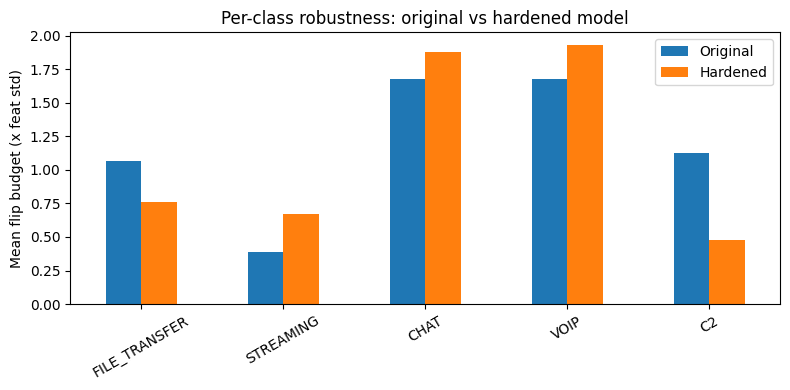

Saved models/category_hardened.joblib


In [17]:
# Per-class robustness: original vs hardened
rng3 = np.random.default_rng(99)

def compute_robustness(model, X_c, y_c):
    flip_b = np.full(len(X_c), np.inf)
    for k in budgets:
        if k == 0:
            continue
        X_p = X_c.copy()
        for feat in top_features:
            delta = rng3.normal(0, k * feat_std[feat], size=len(X_c))
            if is_constrained(feat):
                delta = np.clip(delta, 0, None)
            X_p[feat] = X_p[feat] + delta
        flipped = model.predict(X_p) != y_c.values
        flip_b  = np.where((flip_b == np.inf) & flipped, k, flip_b)

    rob = {}
    for cls in y_c.unique():
        mask = y_c == cls
        b    = np.where(flip_b[mask] == np.inf, budgets[-1], flip_b[mask])
        rob[cls] = b.mean()
    return pd.Series(rob)


print('Computing robustness scores...')
rob_orig     = compute_robustness(best_cat_model, X_correct, y_correct)
rob_hardened = compute_robustness(hardened_model,  X_correct, y_correct)

comparison = pd.DataFrame({'Original': rob_orig, 'Hardened': rob_hardened})
print(comparison.round(4))

comparison.plot.bar(figsize=(8, 4))
plt.ylabel('Mean flip budget (x feat std)')
plt.title('Per-class robustness: original vs hardened model')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

import joblib
joblib.dump(hardened_model, 'models/category_hardened.joblib')
print('Saved models/category_hardened.joblib')

## Step 3.4 - Operational Analysis

In [18]:
# Translate perturbation budget into operational terms
# Budget k means we shifted features by k * their natural std dev.
# Express this as: what % of a features typical range did the adversary move?

feat_range = X_test.max() - X_test.min()

print("Operational interpretation of evasion attack:")
print("-" * 60)

if any(success_flags):
    adv_results = [r for r in results_evasion if r["success"]]
    adv_X_df = pd.DataFrame([r["x_adv"] for r in adv_results], columns=X_c2.columns)
    orig_X_df = X_c2[[r["success"] for r in results_evasion]]

    for feat in top_features[:10]:
        mean_shift = np.abs(adv_X_df[feat].values - orig_X_df[feat].values).mean()
        pct_of_std   = mean_shift / (feat_std[feat] + 1e-9) * 100
        pct_of_range = mean_shift / (feat_range[feat] + 1e-9) * 100
        constrained  = "(increase only)" if is_constrained(feat) else "(bidirectional)"
        print(f"{feat:<40} {pct_of_std:>6.1f}% of std  {pct_of_range:>6.1f}% of range  {constrained}")
else:
    print("No successful evasions -- model was fully robust at the tested budget.")

Operational interpretation of evasion attack:
------------------------------------------------------------
No successful evasions -- model was fully robust at the tested budget.


In [19]:
# Summary framing for writeup
mean_l2_succ = np.mean([r["l2_norm"] for r in results_evasion if r["success"]]) if any(success_flags) else None
mean_steps   = np.mean([r["steps"]   for r in results_evasion if r["success"]]) if any(success_flags) else None

print("=" * 65)
print("OPERATIONAL SUMMARY")
print("=" * 65)
print(f"Attack:          C2 (RDP) -> CHAT (Skype) evasion")
print(f"Method:          Greedy coordinate descent, {MAX_STEPS} max steps")
print(f"Constraint:      Timing/size features increase-only (realistic)")
print(f"")
print(f"Evasion rate (original model): {np.mean(success_flags):.1%}")
print(f"Evasion rate (hardened model): {rate_hardened:.1%}")
if mean_l2_succ:
    print(f"Mean perturbation magnitude:   {mean_l2_succ:.4f} (L2 norm)")
    print(f"Mean steps to evasion:         {mean_steps:.1f}")
print(f"")
print("ATTACK VECTOR REALISM ASSESSMENT")
print("-" * 65)
print("REALISTIC:")
print("  - Padding packets (increasing out_size_* features)")
print("  - Adding artificial delays (increasing *_iat_* features)")
print("  - Splitting large transfers into smaller bursts")
print("  - Injecting dummy traffic to mask flow duration")
print("")
print("THEORETICAL / HIGH-COST:")
print("  - Modifying wavelet energy distribution (requires precise timing)")
print("  - Decreasing packet sizes (impossible post-transmission)")
print("  - Reducing inter-arrival times (requires faster hardware/routing)")
print("")
print("DETECTION STRATEGY RECOMMENDATIONS")
print("-" * 65)
print("1. Monitor for anomalous padding: RDP flows with unusually uniform")
print("   packet sizes are suspicious -- legitimate RDP has variable payloads.")
print("2. Burst pattern analysis: C2 disguised as CHAT will have atypical")
print("   burst durations for a chat protocol.")
print("3. Ensemble voting: combine the hardened model with the original")
print("   to flag samples where the two models disagree.")
print("4. Port/protocol cross-check: RDP on non-standard ports is already")
print("   a strong indicator independent of ML classification.")

OPERATIONAL SUMMARY
Attack:          C2 (RDP) -> CHAT (Skype) evasion
Method:          Greedy coordinate descent, 200 max steps
Constraint:      Timing/size features increase-only (realistic)

Evasion rate (original model): 0.0%
Evasion rate (hardened model): 0.0%

ATTACK VECTOR REALISM ASSESSMENT
-----------------------------------------------------------------
REALISTIC:
  - Padding packets (increasing out_size_* features)
  - Adding artificial delays (increasing *_iat_* features)
  - Splitting large transfers into smaller bursts
  - Injecting dummy traffic to mask flow duration

THEORETICAL / HIGH-COST:
  - Modifying wavelet energy distribution (requires precise timing)
  - Decreasing packet sizes (impossible post-transmission)
  - Reducing inter-arrival times (requires faster hardware/routing)

DETECTION STRATEGY RECOMMENDATIONS
-----------------------------------------------------------------
1. Monitor for anomalous padding: RDP flows with unusually uniform
   packet sizes are su